In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

In [3]:
BASE_DIR = os.path.dirname(os.getcwd())
print(BASE_DIR)

dataset_path = os.path.join(
    BASE_DIR,
    "farming ml datasets",
    "crop water quality.csv"
)
print(dataset_path)

dataset = pd.read_csv(dataset_path)

d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System
d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System\farming ml datasets\crop water quality.csv


In [4]:
dataset

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Trihalomethanes,Turbidity,Check
0,NaN,204.890456,20791.31898,7.300212,368.516441,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,11.168946,77.488213,4.708658,1


In [5]:
dataset = dataset.dropna()

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Organic_carbon   2011 non-null   float64
 6   Trihalomethanes  2011 non-null   float64
 7   Turbidity        2011 non-null   float64
 8   Check            2011 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 157.1 KB


In [7]:
print(pd.isnull(dataset).sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Check              0
dtype: int64


In [8]:
dataset.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Trihalomethanes,Turbidity,Check
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441375,7.134338,333.224672,14.357709,66.400859,3.969729,0.403282
std,1.573337,32.635085,8642.239815,1.584820,41.205172,3.324959,16.077109,0.780346,0.490678
min,0.227499,73.492234,320.942611,1.390871,129.000000,2.200000,8.577013,1.450000,0.000000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,12.124105,55.952664,3.442915,0.000000
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,14.322019,66.542198,3.968177,0.000000
75%,8.052969,216.441070,27182.587065,8.109726,359.330555,16.683049,77.291925,4.514175,1.000000
max,14.000000,317.338124,56488.672410,13.127000,481.030642,27.006707,124.000000,6.494749,1.000000


In [9]:
duplicates = dataset.duplicated().sum()
print(f'The number of duplicates is {duplicates}')

The number of duplicates is 0


In [10]:
dataset_shape = dataset.shape
print(f'The dataset shape is {dataset_shape}')

The dataset shape is (2011, 9)


In [11]:
dataset_object_type = dataset.dtypes
print(dataset_object_type)

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Check                int64
dtype: object


In [12]:
numeric_columns =  dataset.select_dtypes(include='number').columns
print(numeric_columns)

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Organic_carbon',
       'Trihalomethanes', 'Turbidity', 'Check'],
      dtype='object')


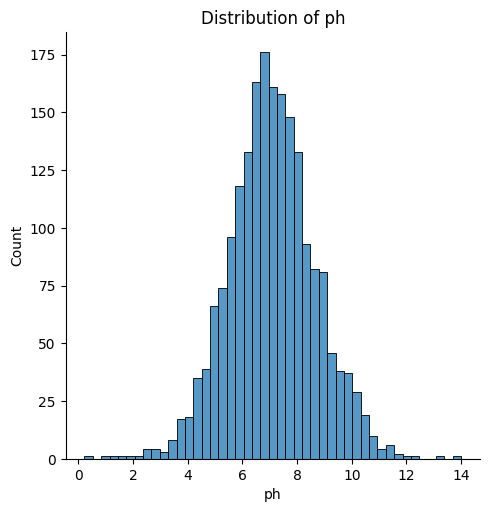

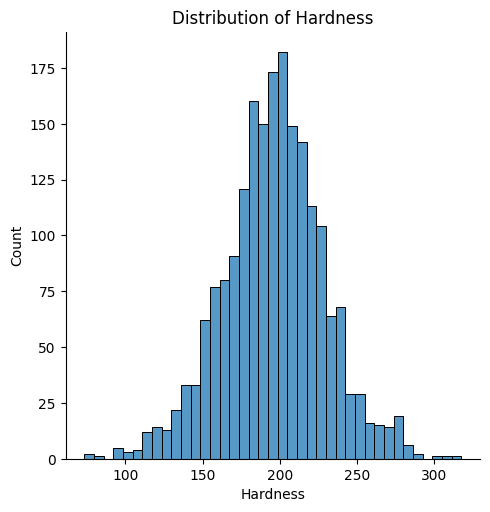

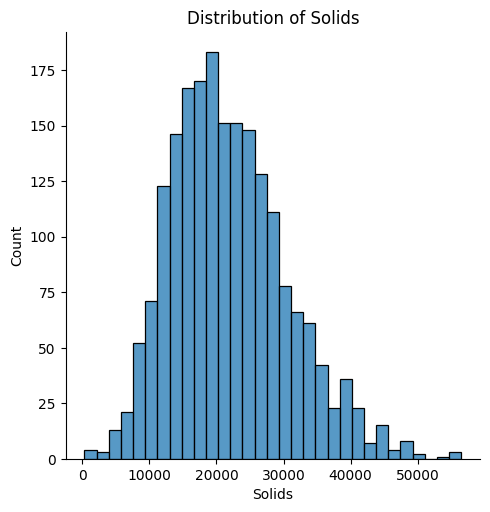

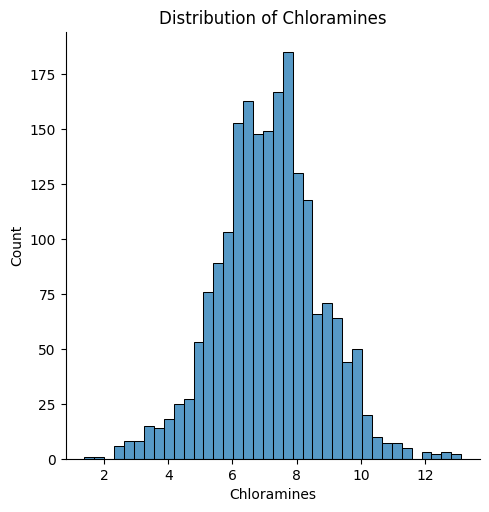

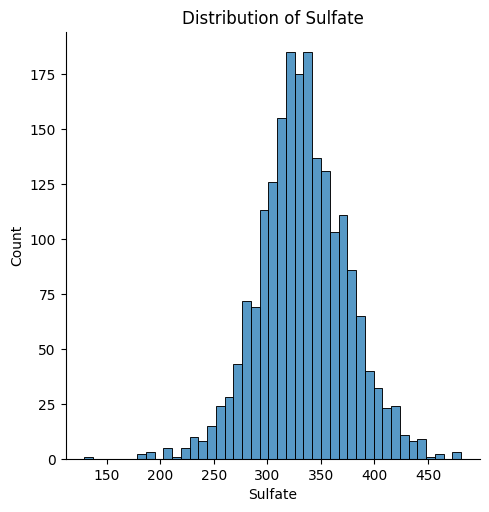

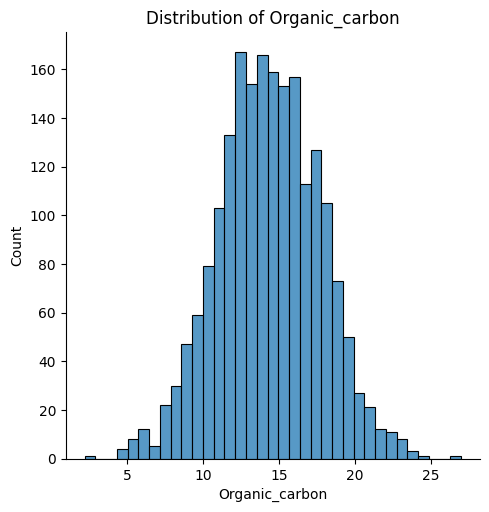

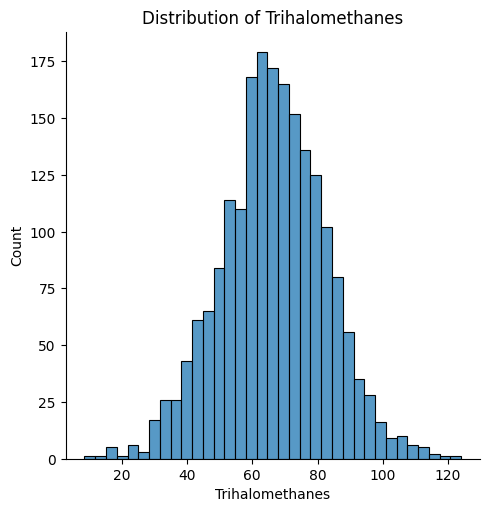

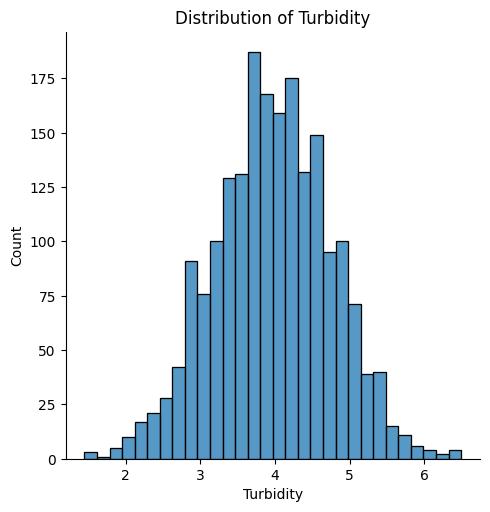

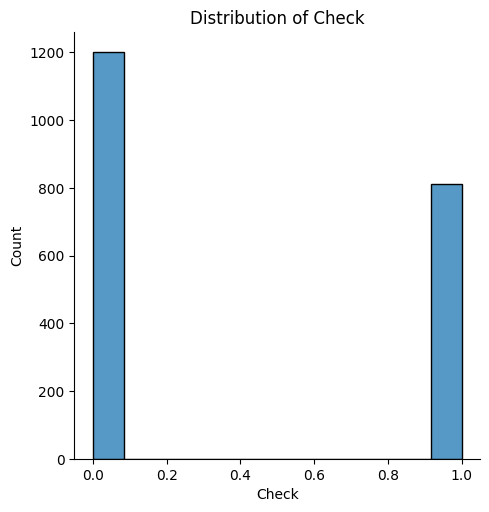

In [13]:
for col in numeric_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [14]:
categorical_columns = dataset.select_dtypes(include='object').columns
print(categorical_columns)

Index([], dtype='object')


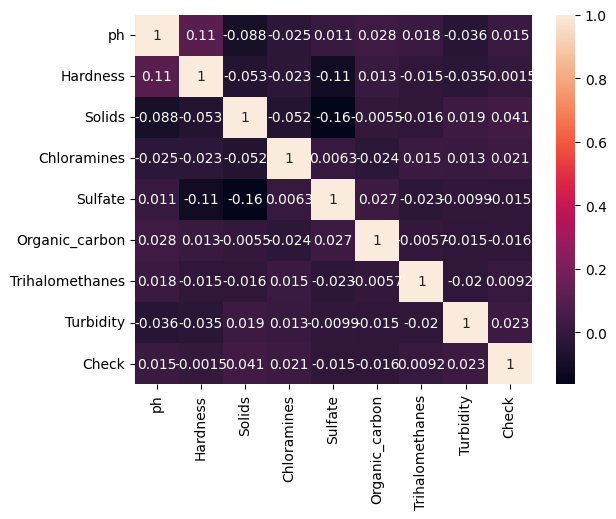

In [15]:
sns.heatmap(dataset[numeric_columns].corr(), annot=True)
plt.show()

In [16]:
x = dataset.drop('Check', axis=1)

In [17]:
x

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Trihalomethanes,Turbidity
3,8.316766,214.373394,22018.41744,8.059332,356.886136,18.436525,100.341674,4.628771
4,9.092223,181.101509,17978.98634,6.546600,310.135738,11.558279,31.997993,4.075075
5,5.584087,188.313324,28748.68774,7.544869,326.678363,8.399735,54.917862,2.559708
6,10.223862,248.071735,28749.71654,7.513408,393.663395,13.789695,84.603556,2.672989
7,8.635849,203.361523,13672.09176,4.563009,303.309771,12.363817,62.798309,4.401425
...,...,...,...,...,...,...,...,...
3267,8.989900,215.047358,15921.41202,6.297312,312.931021,9.899115,55.069304,4.613843
3268,6.702547,207.321086,17246.92035,7.708117,304.510230,16.217303,28.878601,3.442983
3269,11.491011,94.812545,37188.82602,9.263166,258.930600,16.172755,41.558501,4.369264
3270,6.069616,186.659040,26138.78019,7.747547,345.700257,12.067620,60.419921,3.669712


In [18]:
y = dataset['Check']

In [19]:
y

3       0
4       0
5       0
6       0
7       0
       ..
3267    1
3268    1
3269    1
3270    1
3271    1
Name: Check, Length: 2011, dtype: int64

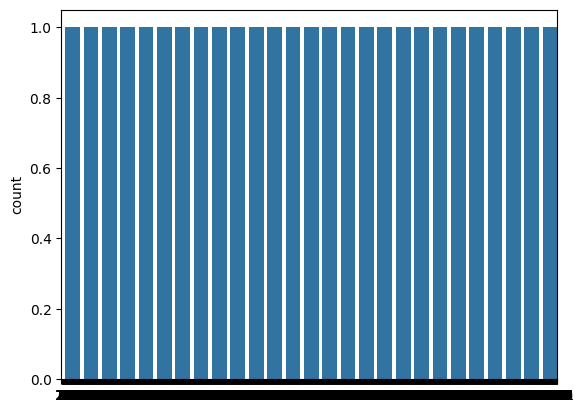

In [20]:
sns.countplot(y)
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
x_train

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Trihalomethanes,Turbidity
417,9.927024,208.490738,19666.992790,8.008618,340.237824,11.360427,85.829113,4.051733
981,8.769676,215.368742,13969.438860,7.548543,322.799070,18.919188,54.755214,3.776718
3204,8.077261,125.302719,23931.282830,8.773162,317.693331,15.279583,62.668356,4.279871
384,9.739562,166.948864,13623.160060,7.235922,385.059134,12.322604,68.505852,2.568080
1332,5.343075,211.662091,45166.912140,6.651801,279.767500,19.682337,70.546862,4.240032
...,...,...,...,...,...,...,...,...
1841,7.965337,151.541889,25274.610300,7.106043,352.316182,15.792625,52.268490,3.390982
2113,6.519848,183.225998,14284.647920,8.389078,373.091575,11.638475,58.661649,3.272286
1401,7.615557,204.869975,8403.284552,6.012316,418.309431,12.742329,67.282328,4.243134
2376,7.899452,210.734124,15896.365940,6.907203,319.886957,18.169921,124.000000,2.853767


In [23]:
x_test

,ph,Hardness,Solids,Chloramines,Sulfate,Organic_carbon,Trihalomethanes,Turbidity
2144,8.157518,236.344440,27931.20840,6.203676,325.323955,13.381575,80.686958,4.469431
854,8.296344,198.197051,17468.99980,8.262904,369.590740,18.026098,44.061625,5.400811
637,6.576845,156.221768,12772.09575,9.759898,341.749378,10.382253,78.305180,3.771314
2299,7.606067,248.041453,14609.97688,6.356555,322.356572,11.706095,94.775244,4.581477
706,5.393346,172.550262,28099.03873,5.789669,372.621943,17.530704,67.273874,4.633855
...,...,...,...,...,...,...,...,...
1182,3.637171,238.943744,10102.48972,7.532192,337.534425,13.818450,49.652834,5.446566
2398,4.881730,136.990466,19105.01490,7.264678,419.716412,13.399392,75.934052,3.050198
1113,8.775486,157.354289,22113.39145,7.931503,304.807845,15.692839,82.929345,4.393944
2883,7.710138,174.350577,31017.23942,8.212234,269.859799,9.320040,51.545335,3.898671


In [24]:
y_train

417     0
981     0
3204    1
384     1
1332    0
       ..
1841    0
2113    0
1401    0
2376    1
1834    0
Name: Check, Length: 1608, dtype: int64

In [25]:
y_test

2144    0
854     0
637     0
2299    0
706     1
       ..
1182    1
2398    1
1113    1
2883    0
2650    0
Name: Check, Length: 403, dtype: int64

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [27]:
x_train

array([[ 1.82114201,  0.37654546, -0.27267943, ..., -0.90829317,
         1.205283  ,  0.11030981],
       [ 1.0869301 ,  0.58705443, -0.9365401 , ...,  1.40309159,
        -0.73460859, -0.24195724],
       [ 0.64766761, -2.16951677,  0.22418194, ...,  0.29014084,
        -0.24060435,  0.40253182],
       ...,
       [ 0.35476643,  0.26572794, -1.58509052, ..., -0.48572307,
         0.04743823,  0.35547462],
       [ 0.53486683,  0.44520678, -0.71202075, ...,  1.17397405,
         3.58822771, -1.42416638],
       [-0.1277584 , -1.41811311, -0.67628217, ..., -0.79867775,
         0.56037488,  1.24680963]], shape=(1608, 8))

In [28]:
x_test

array([[ 0.69858212,  1.22903912,  0.69024041, ..., -0.29024875,
         0.88426688,  0.64533846],
       [ 0.78665218,  0.06149567, -0.52878251, ...,  1.12999458,
        -1.40219148,  1.83834449],
       [-0.30418374, -1.22320475, -1.07605068, ..., -1.20740796,
         0.73557642, -0.24888043],
       ...,
       [ 1.09061574, -1.18854268,  0.01236708, ...,  0.41650987,
         1.02425537,  0.54864826],
       [ 0.41476779, -0.66835232,  1.04981483, ..., -1.53222068,
        -0.934996  , -0.08574834],
       [ 0.5991461 ,  1.2649955 , -0.41807606, ..., -0.25631817,
         1.01326375,  0.70910041]], shape=(403, 8))

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [30]:
models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=10, criterion = 'entropy', random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    }

In [31]:
trained_models = {}
for model_name, model in models.items():
    print(f'---------- Training {model_name} --------------')
    trained_models[model_name] = model.fit(x_train, y_train)
    print('-------------------------------------------------')

---------- Training Logistic Regression --------------
-------------------------------------------------
---------- Training Decision Tree --------------
-------------------------------------------------
---------- Training Random Forest --------------
-------------------------------------------------
---------- Training SVM --------------
-------------------------------------------------
---------- Training KNN --------------
-------------------------------------------------


In [32]:
test_models = {}
for model_name, model in models.items():
    print(f'----------- Testing {model_name} ----------')
    test_models[model_name] = model.predict(x_test)
    print('------------------------------------------')

----------- Testing Logistic Regression ----------
------------------------------------------
----------- Testing Decision Tree ----------
------------------------------------------
----------- Testing Random Forest ----------
------------------------------------------
----------- Testing SVM ----------
------------------------------------------
----------- Testing KNN ----------
------------------------------------------


In [33]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

training_results = {}

for model_name, model in trained_models.items():
    y_train_pred = model.predict(x_train)
    training_results[model_name] = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred, average='weighted'),
        'f1': f1_score(y_train, y_train_pred, average='weighted'),
        'precision': precision_score(y_train, y_train_pred, average='weighted')
    }
for i in training_results:
    print(i, training_results[i])

Logistic Regression {'accuracy': 0.6050995024875622, 'recall': 0.6050995024875622, 'f1': 0.46103000450389614, 'precision': 0.6622446361940298}
Decision Tree {'accuracy': 1.0, 'recall': 1.0, 'f1': 1.0, 'precision': 1.0}
Random Forest {'accuracy': 0.9807213930348259, 'recall': 0.9807213930348259, 'f1': 0.9806518309418456, 'precision': 0.9810833802953852}
SVM {'accuracy': 0.7506218905472637, 'recall': 0.7506218905472637, 'f1': 0.7262622936179239, 'precision': 0.7821119875307009}
KNN {'accuracy': 0.7655472636815921, 'recall': 0.7655472636815921, 'f1': 0.7584455902645253, 'precision': 0.7657871130456294}


In [34]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

testing_results = {}

for model_name, model in trained_models.items():

    y_test_pred = model.predict(x_test)

    testing_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1': f1_score(y_test, y_test_pred, average='weighted'),
        'precision': precision_score(y_test, y_test_pred, average='weighted')
    }

for i in testing_results:
    print(i, testing_results[i])

Logistic Regression {'accuracy': 0.575682382133995, 'recall': 0.575682382133995, 'f1': 0.42328931936591224, 'precision': 0.7561756971964001}
Decision Tree {'accuracy': 0.5880893300248139, 'recall': 0.5880893300248139, 'f1': 0.5886578961757107, 'precision': 0.5893412044826}
Random Forest {'accuracy': 0.6501240694789082, 'recall': 0.6501240694789082, 'f1': 0.6328204473247527, 'precision': 0.647933828998787}
SVM {'accuracy': 0.6724565756823822, 'recall': 0.6724565756823822, 'f1': 0.6411291384455678, 'precision': 0.6924881261521041}
KNN {'accuracy': 0.6178660049627791, 'recall': 0.6178660049627791, 'f1': 0.6048649437643745, 'precision': 0.6100749753195123}


In [36]:
final_model = trained_models['SVM']

In [37]:
y_pred = final_model.predict(x_test)

In [38]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,

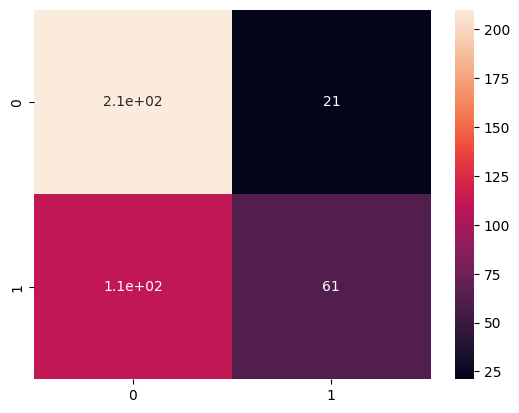

In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [40]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.65      0.91      0.76       231
           1       0.74      0.35      0.48       172

    accuracy                           0.67       403
   macro avg       0.70      0.63      0.62       403
weighted avg       0.69      0.67      0.64       403



In [41]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(estimator=final_model, X=x_train, y=y_train, cv=10)
print(cv.std())
print(cv.mean())

0.020435986476106574
0.6890411490683229


In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy of the model is {round(accuracy, 2)*100}')

The accuracy of the model is 67.0


In [43]:
best_model = trained_models['SVM']
jb.dump(sc, 'crop_water_scaler.joblib')
jb.dump(best_model, 'crop_water_test.joblib')

['crop_water_test.joblib']